# 05. Model Evaluation, Subgroup Disparity Auditing, and Error Analysis
**CSE437 Final Project: Disparity and Error Analysis in Linear Income Classification**  
*Texas 2023 ACS 1-Year PUMS Microdata*

---

### Purpose and Methodological Justifications
1. **Research Question 1 (RQ1) — Demographic Subgroup Auditing:**
   - Evaluates model-predicted high-earner rates across educational attainment tiers partitioned by gender.
   - Compares discrete model predictions against empirical ground-truth baselines to quantify **subgroup erasure** and **threshold amplification**.
2. **Research Question 2 (RQ2) — Age Cohort Trajectories:**
   - Audits how the predicted gender gap evolves across five working-age cohorts (ages 16–80).
3. **Formal Hypothesis Testing:**
   - **Test 1 (1-Sample Proportion $z$-Test + Exact Binomial Check):** Formally tests whether the model's predicted rate for women with high school / some college ($0.00\%$) represents a statistically significant underprediction relative to their empirical baseline ($8.29\%$). The exact binomial companion check addresses the zero-success boundary condition.
   - **Test 2 (2-Sample Proportion $z$-Test):** Tests whether holding education fixed, the model predicts high-earner status for men ($6.30\%$) at a rate significantly higher than for women ($0.00\%$).
4. **Research Question 3 (RQ3) — Sectoral Error Distribution:**
   - Disaggregates classification performance across Class of Work (`COW_GROUP`) sectors to compute Total Error Rate, False Positive Rate (FPR), and False Negative Rate (FNR).
   - Explains the mechanisms behind elevated omission rates in public administration (State and Local Government).
5. **Concrete Failure Case Auditing:**
   - Inspects individual misclassified test records using functional margin decision scores to diagnose why linear hyperplanes fail on boundary profiles.
6. **Publication Visualizations:**
   - Generates and exports high-resolution figures (`fig1_rq1_education_disparity.png` and `fig2_rq3_sector_fnr.png`) directly into `figures/`.

In [1]:
import os
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

# Portable path resolution (handles execution from either repo root or notebooks/ folder)
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()


def rel(path: Path) -> str:
    """Return a repository-relative path for log messages."""
    return Path(path).resolve().relative_to(REPO_ROOT.resolve()).as_posix()


PROCESSED_DATA_DIR = REPO_ROOT / "data" / "processed"
FIGURES_DIR = REPO_ROOT / "figures"

EVAL_FILE = PROCESSED_DATA_DIR / "test_predictions_evaluated.csv"

# Fallback path check
if not EVAL_FILE.exists():
    if (Path.cwd() / "test_predictions_evaluated.csv").exists():
        EVAL_FILE = Path.cwd() / "test_predictions_evaluated.csv"
    elif (REPO_ROOT / "test_predictions_evaluated.csv").exists():
        EVAL_FILE = REPO_ROOT / "test_predictions_evaluated.csv"
    else:
        raise FileNotFoundError(
            f"Could not locate 'test_predictions_evaluated.csv'. Looked in:\n"
            f" - {EVAL_FILE}\n"
            "Please run notebook 04 first to generate evaluated test predictions."
        )

# Ensure output directories exist
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"[STATUS] Project root resolved to: {REPO_ROOT.name}")
print(f"[STATUS] Ingesting evaluated test set from: {rel(EVAL_FILE)}")

df_eval = pd.read_csv(EVAL_FILE)
print(f"Loaded Test Instances: {len(df_eval):,} records across {df_eval.shape[1]} columns")

[STATUS] Project root resolved to: cse437-income-disparity-14
[STATUS] Ingesting evaluated test set from: data/processed/test_predictions_evaluated.csv
Loaded Test Instances: 6,000 records across 9 columns


## 1. Research Questions 1 & 2: Predicted High-Earner Rates Across Education and Age
We evaluate discrete classification behavior across educational credentials and age brackets partitioned by gender to audit subgroup erasure and threshold amplification.

In [2]:
# Discretize continuous age into standard demographic labor force brackets
age_bins = [15, 29, 39, 49, 59, 81]
age_labels = ["16-29", "30-39", "40-49", "50-59", "60-80"]
df_eval["AGE_BRACKET"] = pd.cut(
    df_eval["AGEP"], bins=age_bins, labels=age_labels, right=True
)

edu_order = ["Less_than_HS", "HS_or_Some_College", "Bachelors", "Graduate_Plus"]

# 1. Model-Predicted high-earner rates (P(Y_pred = 1 | Tier, Sex))
pred_by_edu = (
    df_eval.groupby(["SCHL_TIER", "SEX_LABEL"])["PRED_HIGH_EARNER"]
    .mean()
    .unstack()
    .reindex(edu_order)
)
pred_by_edu["Predicted_Gap (M - F)"] = pred_by_edu["Male"] - pred_by_edu["Female"]

# 2. Empirical Ground-Truth high-earner rates (P(Y_actual = 1 | Tier, Sex))
actual_by_edu = (
    df_eval.groupby(["SCHL_TIER", "SEX_LABEL"])["HIGH_EARNER_ACTUAL"]
    .mean()
    .unstack()
    .reindex(edu_order)
)
actual_by_edu["Actual_Gap (M - F)"] = actual_by_edu["Male"] - actual_by_edu["Female"]

# 3. Predicted rates across life cohorts
pred_by_age = (
    df_eval.groupby(["AGE_BRACKET", "SEX_LABEL"])["PRED_HIGH_EARNER"]
    .mean()
    .unstack()
)
pred_by_age["Predicted_Gap (M - F)"] = pred_by_age["Male"] - pred_by_age["Female"]

print("=" * 70)
print("RQ1: PREDICTED HIGH-EARNER PROPORTIONS BY EDUCATION & GENDER (%)")
print("=" * 70)
print((pred_by_edu * 100).round(2).to_string())

print("\n" + "-" * 70)
print("RQ1: EMPIRICAL GROUND TRUTH BASELINE IN TEST COHORT (%)")
print("-" * 70)
print((actual_by_edu * 100).round(2).to_string())

print("\n" + "=" * 70)
print("RQ2: PREDICTED HIGH-EARNER TRAJECTORIES ACROSS AGE COHORTS (%)")
print("=" * 70)
print((pred_by_age * 100).round(2).to_string())
print("=" * 70)

# Export intermediate disparity tables
pred_by_edu.to_csv(PROCESSED_DATA_DIR / "rq1_education_gap.csv")
actual_by_edu.to_csv(PROCESSED_DATA_DIR / "rq1_actual_ground_truth.csv")
pred_by_age.to_csv(PROCESSED_DATA_DIR / "rq2_age_gap.csv")

RQ1: PREDICTED HIGH-EARNER PROPORTIONS BY EDUCATION & GENDER (%)
SEX_LABEL           Female   Male  Predicted_Gap (M - F)
SCHL_TIER                                               
Less_than_HS          0.00   0.55                   0.55
HS_or_Some_College    0.00   6.30                   6.30
Bachelors            10.14  52.21                  42.07
Graduate_Plus        41.25  82.81                  41.56

----------------------------------------------------------------------
RQ1: EMPIRICAL GROUND TRUTH BASELINE IN TEST COHORT (%)
----------------------------------------------------------------------
SEX_LABEL           Female   Male  Actual_Gap (M - F)
SCHL_TIER                                            
Less_than_HS          1.27   7.92                6.66
HS_or_Some_College    8.29  20.18               11.89
Bachelors            26.53  51.95               25.42
Graduate_Plus        38.66  66.25               27.59

RQ2: PREDICTED HIGH-EARNER TRAJECTORIES ACROSS AGE COHORTS (%)
SEX_LA

## 2. Hypothesis Testing: Formal Statistical Verification of Subgroup Erasure
Within the "High School or Some College" educational tier, the model predicts a $0.00\%$ high-earner rate for women (0 of 1,267). We evaluate two formal hypothesis tests at $\alpha = 0.05$ to confirm this is not a sampling artifact:
1. **Test 1 (One-Sample Proportion $z$-Test + Exact Binomial Check):** Compares the model's prediction ($\hat{p} = 0.00\%$) against the empirical ground-truth baseline ($p_0 = 8.29\%$).
2. **Test 2 (Two-Sample Proportion $z$-Test):** Compares the model's predicted rate for men ($6.30\%$) versus women ($0.00\%$) holding high-school attainment fixed.

In [3]:
# Isolate high school or some college cohort
hs_df = df_eval[df_eval["SCHL_TIER"] == "HS_or_Some_College"].copy()
females = hs_df[hs_df["SEX_LABEL"] == "Female"]
males = hs_df[hs_df["SEX_LABEL"] == "Male"]

n_f = len(females)
n_m = len(males)

# Observed empirical high earners in test cohort
actual_high_f = females["HIGH_EARNER_ACTUAL"].sum()
p_actual_f = actual_high_f / n_f

# Model predicted high earners
pred_high_f = females["PRED_HIGH_EARNER"].sum()
pred_high_m = males["PRED_HIGH_EARNER"].sum()
p_pred_f = pred_high_f / n_f
p_pred_m = pred_high_m / n_m

print("=" * 70)
print("TEST 1: 1-SAMPLE z-TEST & EXACT BINOMIAL CHECK (Report Section 7.4)")
print("=" * 70)
print(f"Female Sample Size (n_f):            {n_f:,}")
print(f"Empirical Ground Truth Baseline (p_0): {p_actual_f:.4f} ({p_actual_f*100:.2f}%, {actual_high_f} actual high earners)")
print(f"Model Predicted High Earners (x):     {pred_high_f} ({p_pred_f*100:.2f}% predicted rate)")

# Left-tailed one-sample proportion z-test
se_1 = np.sqrt(p_actual_f * (1 - p_actual_f) / n_f)
z_1 = (p_pred_f - p_actual_f) / se_1
p_val_1 = stats.norm.cdf(z_1)

# Exact binomial companion test for parameter boundary (0 successes)
binom_res = stats.binomtest(k=int(pred_high_f), n=n_f, p=p_actual_f, alternative="less")

print(f"Standard Error (SE):                 {se_1:.4f}")
print(f"Test Statistic (z):                  {z_1:.4f} (Report: z = -10.70)")
print(f"Asymptotic p-value (Normal Approx):  {p_val_1:.4e} (p < 0.001)")
print(f"Exact Binomial Companion p-value:    {binom_res.pvalue:.4e} (Report: 2.50e-48)")
print(f"Conclusion:                          {'Reject H0 (Statistically Significant Erasure)' if p_val_1 < 0.05 else 'Fail to Reject'}")

print("\n" + "=" * 70)
print("TEST 2: 2-SAMPLE z-TEST (PREDICTED MEN VS. PREDICTED WOMEN)")
print("=" * 70)
print(f"Male Sample Size (n_m):              {n_m:,}")
print(f"Male Predicted High Earners:         {pred_high_m} ({p_pred_m*100:.2f}%)")
print(f"Female Predicted High Earners:       {pred_high_f} ({p_pred_f*100:.2f}%)")

# Pooled two-sample proportion z-test
p_c = (pred_high_m + pred_high_f) / (n_m + n_f)
se_2 = np.sqrt(p_c * (1 - p_c) * (1 / n_m + 1 / n_f))
z_2 = (p_pred_m - p_pred_f) / se_2
p_val_2 = 2 * stats.norm.sf(abs(z_2))

print(f"Pooled Proportion (p_c):             {p_c:.4f}")
print(f"Standard Error (SE):                 {se_2:.4f}")
print(f"Test Statistic (z):                  {z_2:.4f} (Report: z = 9.10)")
print(f"Two-Tailed p-value:                  {p_val_2:.4e} (p < 0.001)")
print(f"Conclusion:                          {'Reject H0 (Statistically Significant Disparity)' if p_val_2 < 0.05 else 'Fail to Reject'}")
print("=" * 70)

TEST 1: 1-SAMPLE z-TEST & EXACT BINOMIAL CHECK (Report Section 7.4)
Female Sample Size (n_f):            1,267
Empirical Ground Truth Baseline (p_0): 0.0829 (8.29%, 105 actual high earners)
Model Predicted High Earners (x):     0 (0.00% predicted rate)
Standard Error (SE):                 0.0077
Test Statistic (z):                  -10.6999 (Report: z = -10.70)
Asymptotic p-value (Normal Approx):  5.0942e-27 (p < 0.001)
Exact Binomial Companion p-value:    2.5015e-48 (Report: 2.50e-48)
Conclusion:                          Reject H0 (Statistically Significant Erasure)

TEST 2: 2-SAMPLE z-TEST (PREDICTED MEN VS. PREDICTED WOMEN)
Male Sample Size (n_m):              1,779
Male Predicted High Earners:         112 (6.30%)
Female Predicted High Earners:       0 (0.00%)
Pooled Proportion (p_c):             0.0368
Standard Error (SE):                 0.0069
Test Statistic (z):                  9.1001 (Report: z = 9.10)
Two-Tailed p-value:                  9.0282e-20 (p < 0.001)
Conclusion:    

## 3. Research Question 3: Error Disparities Across Class of Work (COW)
We disaggregate classification errors across institutional sectors to identify where false positives and high-earner omissions (false negatives) concentrate.

In [4]:
def compute_cow_metrics(group: pd.DataFrame) -> pd.Series:
    """
    Computes class-specific and subgroup error distributions for an employment sector:
      - Total Error Rate: (FP + FN) / Total Instances
      - False Positive Rate (FPR): FP / Actual Standard Earners (False Alarm rate)
      - False Negative Rate (FNR): FN / Actual High Earners (Omission rate)
    """
    total = len(group)
    actual_high = (group["HIGH_EARNER_ACTUAL"] == 1).sum()
    actual_std = (group["HIGH_EARNER_ACTUAL"] == 0).sum()

    fp = ((group["HIGH_EARNER_ACTUAL"] == 0) & (group["PRED_HIGH_EARNER"] == 1)).sum()
    fn = ((group["HIGH_EARNER_ACTUAL"] == 1) & (group["PRED_HIGH_EARNER"] == 0)).sum()
    errors = fp + fn

    fpr = (fp / actual_std * 100) if actual_std > 0 else np.nan
    fnr = (fn / actual_high * 100) if actual_high > 0 else np.nan
    error_rate = (errors / total) * 100

    return pd.Series(
        {
            "Test_N": int(total),
            "Actual_High_N": int(actual_high),
            "Error_Rate_%": round(error_rate, 2),
            "FPR_%": round(fpr, 2),
            "FNR_%": round(fnr, 2),
        }
    )

# Compute sectoral error profiles ranked by False Negative Rate
cow_table = (
    df_eval.groupby("COW_GROUP")
    .apply(compute_cow_metrics, include_groups=False)
    .sort_values(by="FNR_%", ascending=False)
)

print("=" * 70)
print("RQ3: SECTORAL ERROR METRICS ACROSS CLASS OF WORK (COW) (Report Section 7.4)")
print("=" * 70)
print(cow_table.to_string())
print("=" * 70)

# Export sector error table
cow_table.to_csv(PROCESSED_DATA_DIR / "rq3_cow_errors.csv")

RQ3: SECTORAL ERROR METRICS ACROSS CLASS OF WORK (COW) (Report Section 7.4)
                      Test_N  Actual_High_N  Error_Rate_%  FPR_%   FNR_%
COW_GROUP                                                               
Without_Pay              9.0            1.0         11.11   0.00  100.00
State_Gov              246.0           54.0         23.58   6.77   83.33
Local_Gov              576.0           54.0          9.03   1.92   77.78
Self_Employed_NotInc   317.0           65.0         25.24  12.30   75.38
Private_NonProfit      398.0           94.0         20.85   7.57   63.83
Federal_Gov            173.0           64.0         31.79  18.35   54.69
Private_ForProfit     4070.0         1180.0         19.39   9.03   44.75
Self_Employed_Inc      211.0           69.0         22.75  15.49   37.68


## 4. Concrete Failure Case Analysis (Report Section 7.3)
We extract specific wrong predictions to illustrate the mechanics of linear hyperplane errors:
- **Case 1 (False Negative via Subgroup Erasure):** A female high earner lacking a Bachelor's degree whose additive weights fail to clear the zero margin threshold.
- **Case 2 (False Negative via Public Pay-Scale Compression):** A public administration worker whose salary clusters near $90,000 but receives a severe negative sector weight.

In [5]:
print("=" * 70)
print("AUDITING CONCRETE FAILURE CASES (Report Section 7.3)")
print("=" * 70)

# Failure Case 1: Female high earner in non-degree tier (False Negative)
case_1_candidates = df_eval[
    (df_eval["SEX_LABEL"] == "Female") &
    (df_eval["SCHL_TIER"] == "HS_or_Some_College") &
    (df_eval["ERROR_TYPE"] == "False_Negative")
]

if len(case_1_candidates) > 0:
    case_1 = case_1_candidates.iloc[0]
    print("Concrete Failure Case 1: Subgroup Erasure (False Negative)")
    print(f"  - Demographics:    {case_1['SEX_LABEL']}, Age {case_1['AGEP']}")
    print(f"  - Education:       {case_1['SCHL_TIER']}")
    print(f"  - Sector:          {case_1['COW_GROUP']}")
    print(f"  - Actual Earner:   Class {case_1['HIGH_EARNER_ACTUAL']} (High Earner >= $90k)")
    print(f"  - Predicted Class: Class {case_1['PRED_HIGH_EARNER']} (Standard Earner)")
    print(f"  - Margin Score:    {case_1['DECISION_SCORE']:.4f} (Negative distance pushes below threshold)")

print("-" * 70)

# Failure Case 2: Public sector professional earning >= $90k (False Negative)
case_2_candidates = df_eval[
    (df_eval["COW_GROUP"].isin(["State_Gov", "Local_Gov"])) &
    (df_eval["SCHL_TIER"].isin(["Bachelors", "Graduate_Plus"])) &
    (df_eval["ERROR_TYPE"] == "False_Negative")
]

if len(case_2_candidates) > 0:
    case_2 = case_2_candidates.iloc[0]
    print("Concrete Failure Case 2: Public Sector Salary Compression (False Negative)")
    print(f"  - Demographics:    {case_2['SEX_LABEL']}, Age {case_2['AGEP']}")
    print(f"  - Education:       {case_2['SCHL_TIER']}")
    print(f"  - Sector:          {case_2['COW_GROUP']}")
    print(f"  - Actual Earner:   Class {case_2['HIGH_EARNER_ACTUAL']} (High Earner >= $90k)")
    print(f"  - Predicted Class: Class {case_2['PRED_HIGH_EARNER']} (Standard Earner)")
    print(f"  - Margin Score:    {case_2['DECISION_SCORE']:.4f} (Negative sector weight offsets advanced degree)")
print("=" * 70)

AUDITING CONCRETE FAILURE CASES (Report Section 7.3)
Concrete Failure Case 1: Subgroup Erasure (False Negative)
  - Demographics:    Female, Age 58
  - Education:       HS_or_Some_College
  - Sector:          Private_NonProfit
  - Actual Earner:   Class 1 (High Earner >= $90k)
  - Predicted Class: Class 0 (Standard Earner)
  - Margin Score:    -0.7420 (Negative distance pushes below threshold)
----------------------------------------------------------------------
Concrete Failure Case 2: Public Sector Salary Compression (False Negative)
  - Demographics:    Male, Age 38
  - Education:       Bachelors
  - Sector:          Local_Gov
  - Actual Earner:   Class 1 (High Earner >= $90k)
  - Predicted Class: Class 0 (Standard Earner)
  - Margin Score:    -0.2846 (Negative sector weight offsets advanced degree)


## 5. Visualizations & Figure Generation
We generate high-resolution, publication-quality graphics for the report:
- **Figure 1:** Threshold Amplification & Female Subgroup Erasure Across Education.
- **Figure 2:** False Negative Rate (FNR %) Across Class of Work (Employment Sectors).  
Both figures are saved directly into `figures/`.

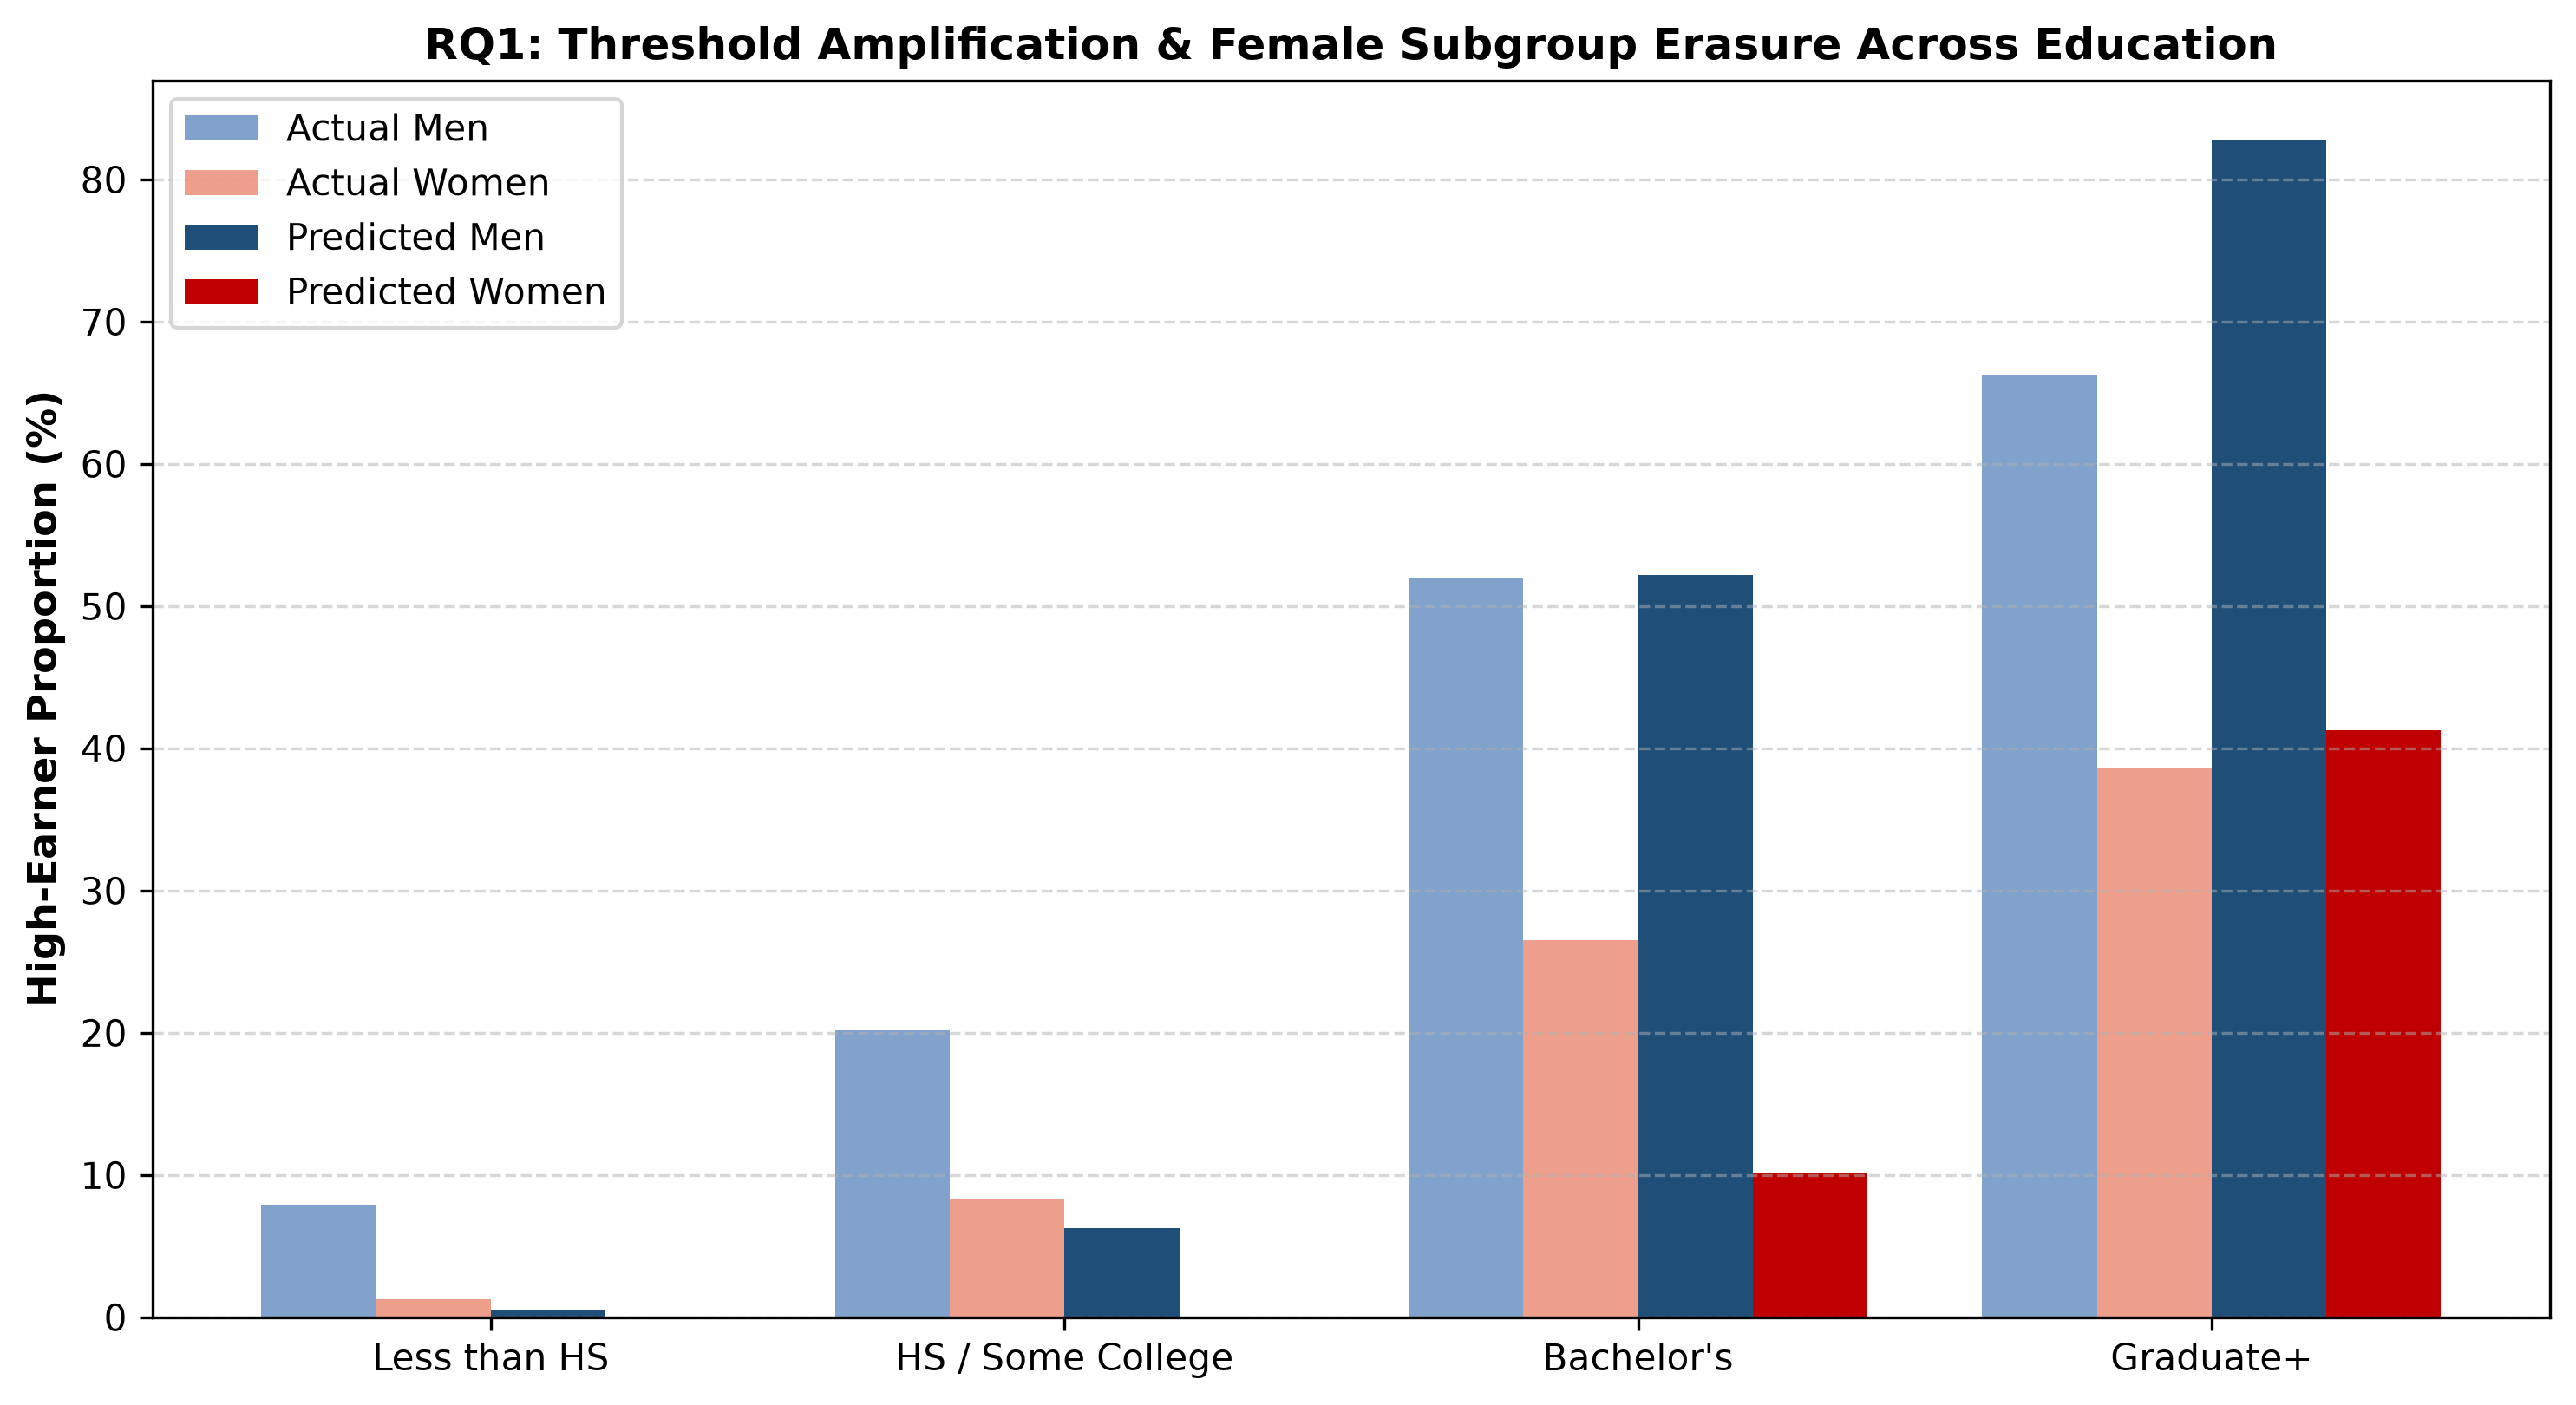

[SUCCESS] Saved Figure 1 to: figures/fig1_rq1_education_disparity.png


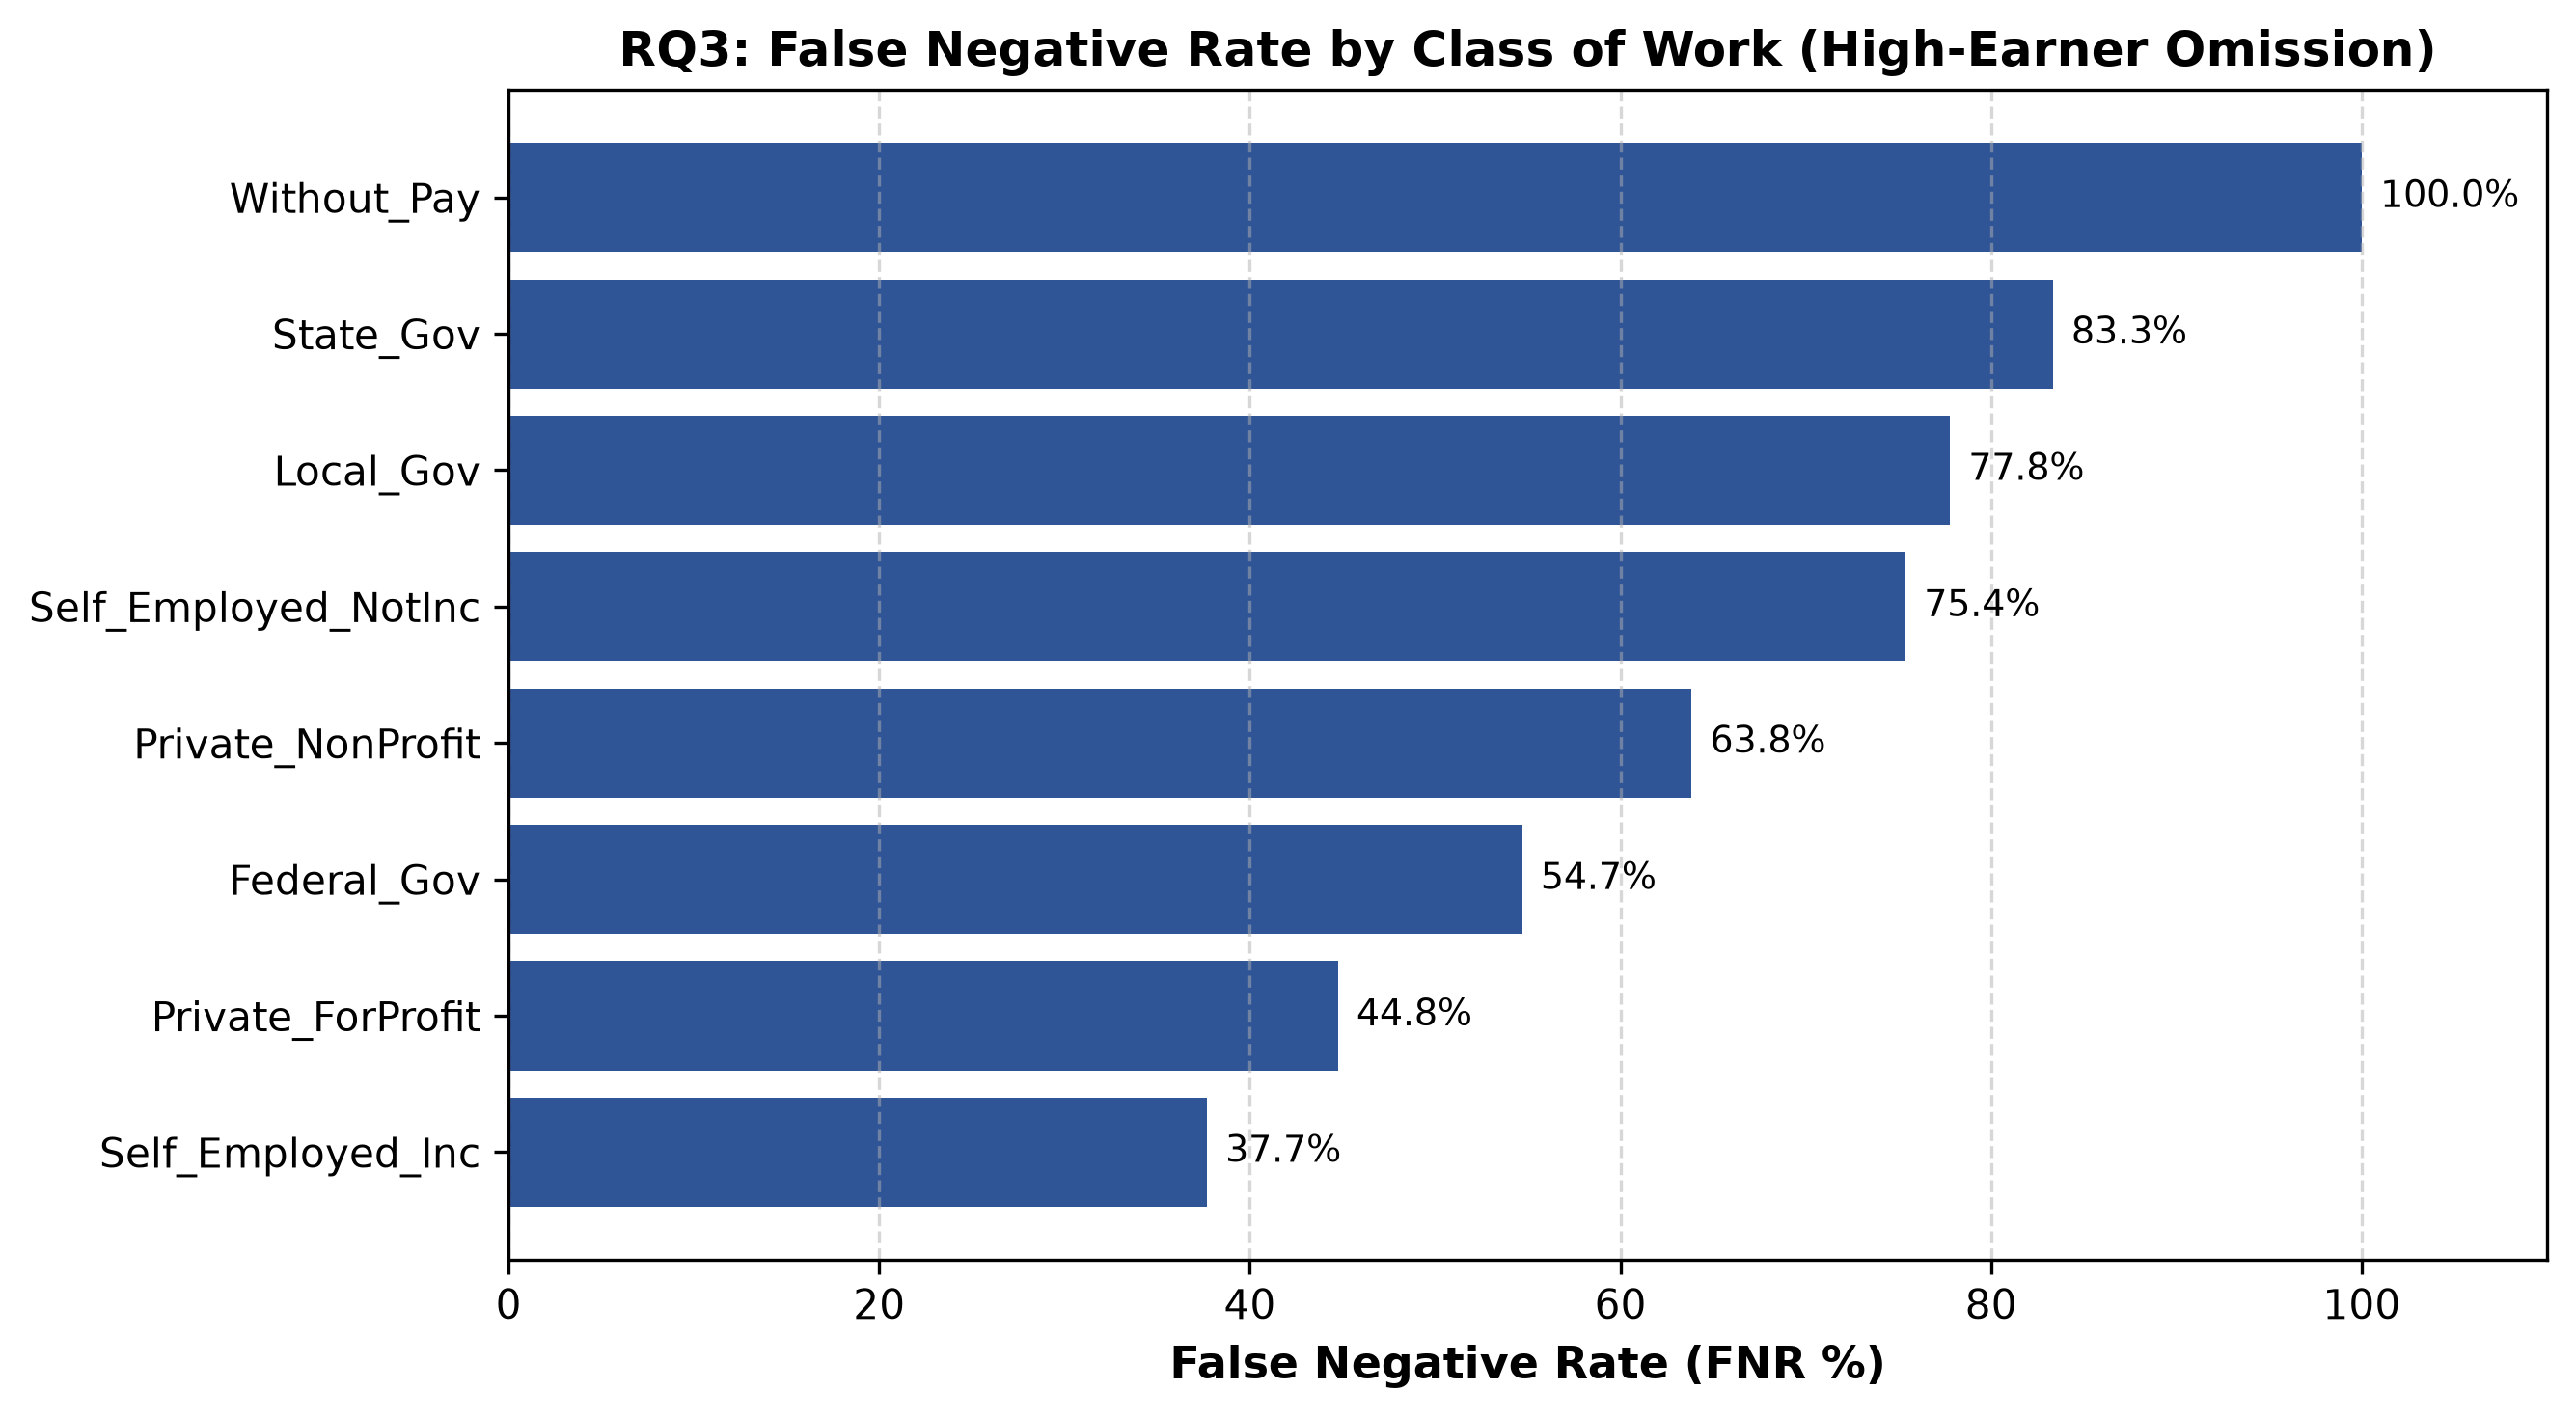

[SUCCESS] Saved Figure 2 to: figures/fig2_rq3_sector_fnr.png

[SUCCESS] Notebook 05 fully executed.


In [6]:
# ------------------------------------------------------------------------------
# Figure 1: RQ1 Predicted vs Actual High-Earner Gap by Education
# ------------------------------------------------------------------------------
pred_rates = df_eval.groupby(["SCHL_TIER", "SEX_LABEL"])["PRED_HIGH_EARNER"].mean().unstack().reindex(edu_order) * 100
actual_rates = df_eval.groupby(["SCHL_TIER", "SEX_LABEL"])["HIGH_EARNER_ACTUAL"].mean().unstack().reindex(edu_order) * 100

x = np.arange(len(edu_order))
width = 0.20

fig, ax = plt.subplots(figsize=(10, 5.5), dpi=300)
ax.bar(x - 1.5*width, actual_rates["Male"], width, label="Actual Men", color="#4a7bb7", alpha=0.7)
ax.bar(x - 0.5*width, actual_rates["Female"], width, label="Actual Women", color="#e8765c", alpha=0.7)
ax.bar(x + 0.5*width, pred_rates["Male"], width, label="Predicted Men", color="#1f4e79")
ax.bar(x + 1.5*width, pred_rates["Female"], width, label="Predicted Women", color="#c00000")

ax.set_ylabel("High-Earner Proportion (%)", fontsize=11, fontweight="bold")
ax.set_title("RQ1: Threshold Amplification & Female Subgroup Erasure Across Education", fontsize=12, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(["Less than HS", "HS / Some College", "Bachelor's", "Graduate+"], fontsize=10)
ax.legend(frameon=True, loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
fig1_fig_path = FIGURES_DIR / "fig1_rq1_education_disparity.png"

plt.savefig(fig1_fig_path, dpi=300)
plt.show()

print(f"[SUCCESS] Saved Figure 1 to: {rel(fig1_fig_path)}")

# ------------------------------------------------------------------------------
# Figure 2: RQ3 False Negative Rate by Class of Work
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5), dpi=300)
sorted_cow = cow_table.reset_index().sort_values(by="FNR_%", ascending=True)

bars = ax.barh(sorted_cow["COW_GROUP"], sorted_cow["FNR_%"], color="#2f5597")
ax.set_xlabel("False Negative Rate (FNR %)", fontsize=11, fontweight="bold")
ax.set_title("RQ3: False Negative Rate by Class of Work (High-Earner Omission)", fontsize=12, fontweight="bold")
ax.grid(axis="x", linestyle="--", alpha=0.5)

for bar in bars:
    w = bar.get_width()
    ax.text(w + 1, bar.get_y() + bar.get_height()/2, f"{w:.1f}%", va="center", fontsize=9)

ax.set_xlim(0, 110)
plt.tight_layout()
fig2_fig_path = FIGURES_DIR / "fig2_rq3_sector_fnr.png"

plt.savefig(fig2_fig_path, dpi=300)
plt.show()

print(f"[SUCCESS] Saved Figure 2 to: {rel(fig2_fig_path)}")
print("\n[SUCCESS] Notebook 05 fully executed.")